Missing values per column:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


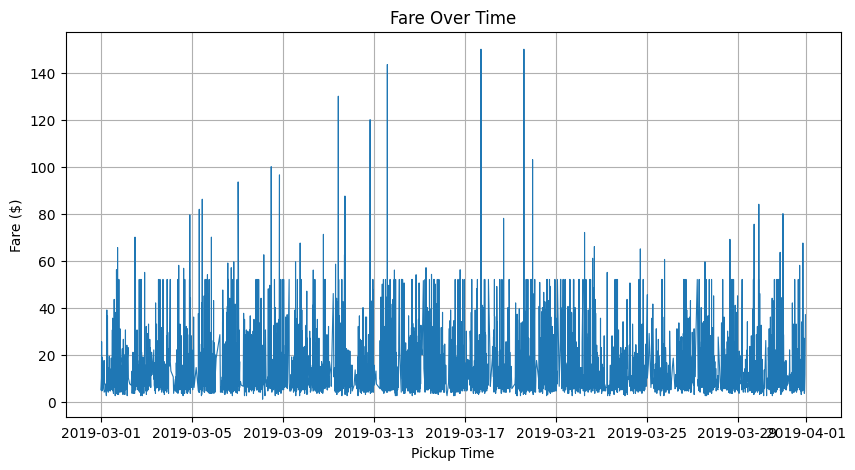

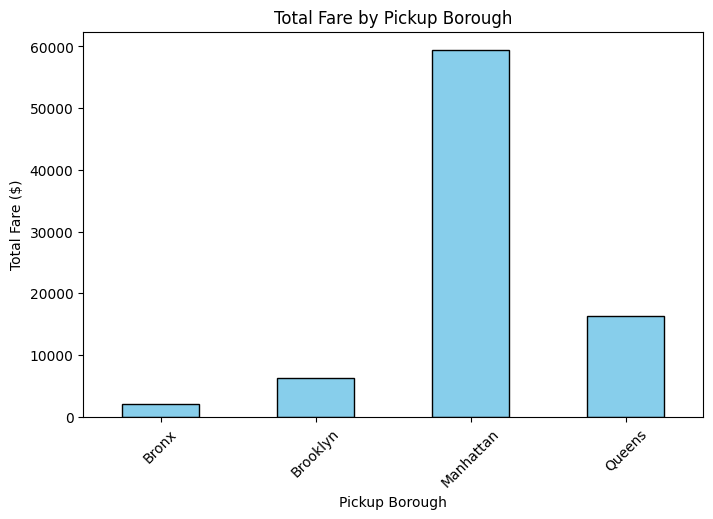

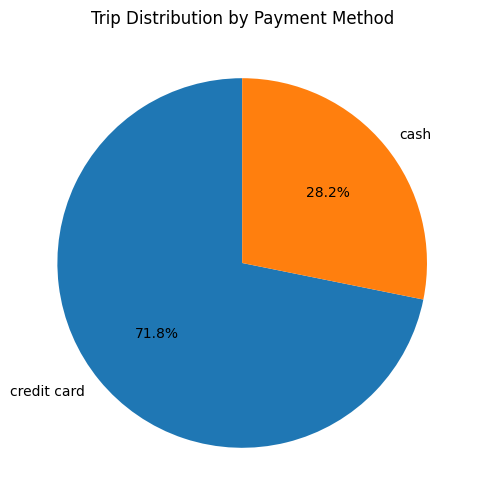

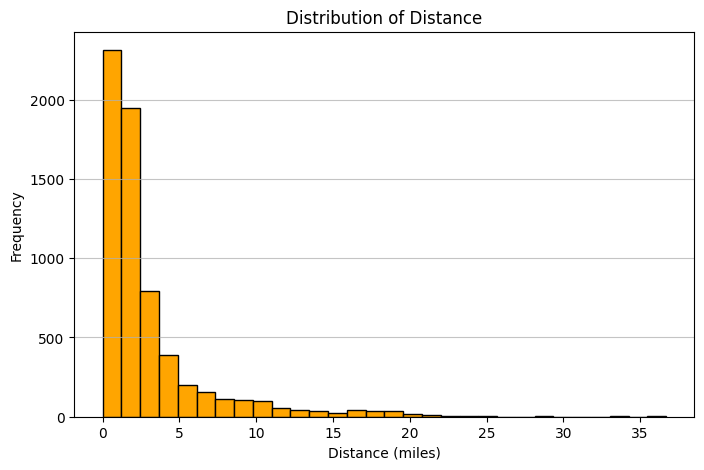

<Figure size 800x500 with 0 Axes>

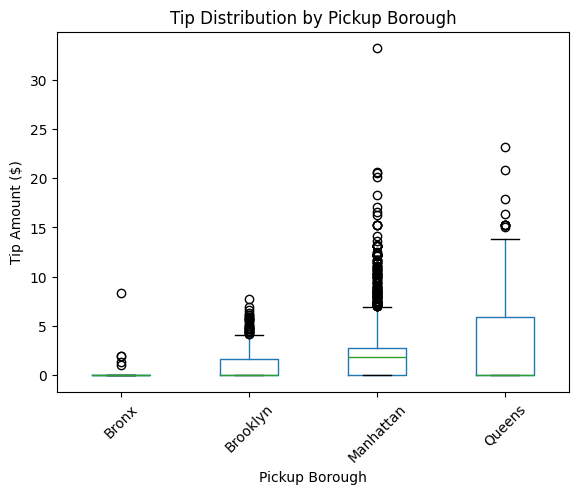

/tmp/ipykernel_600/140251126.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="pickup_borough", palette="viridis")


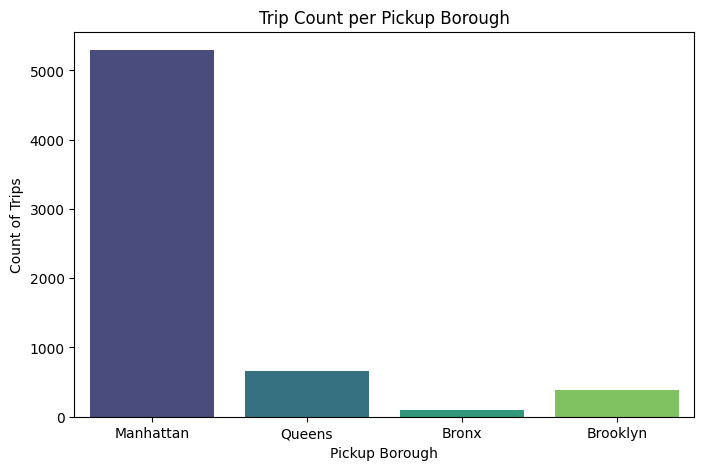

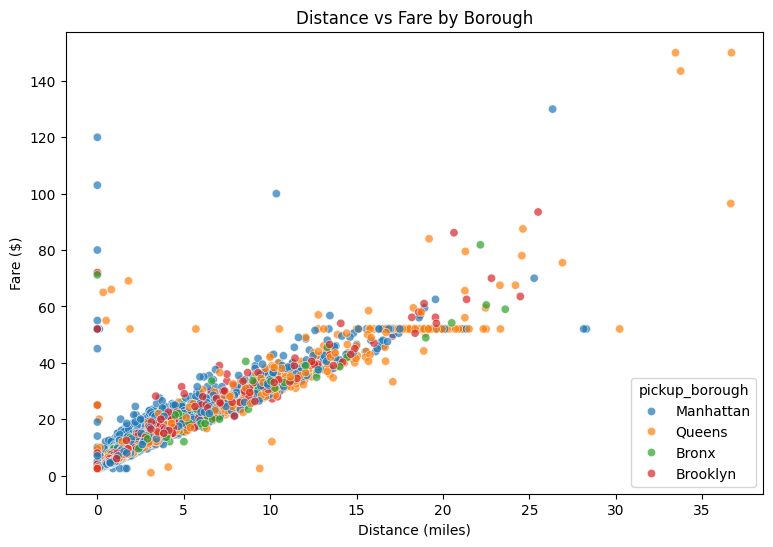

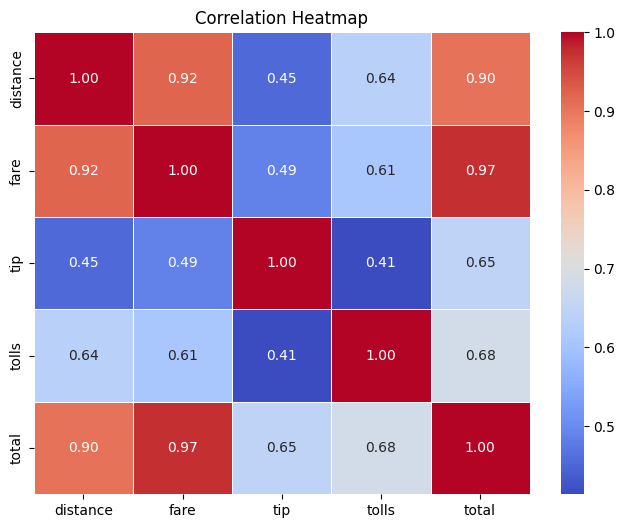

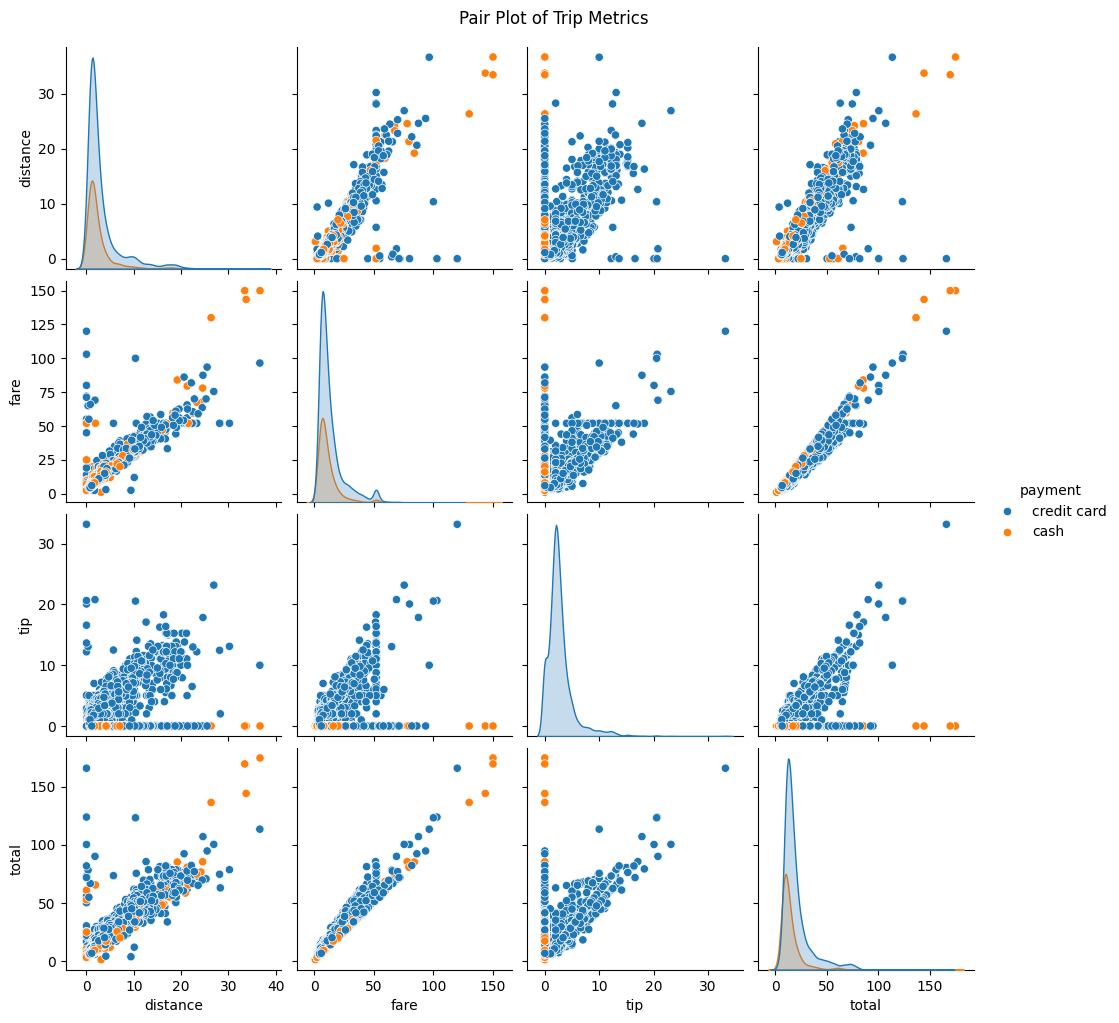

/tmp/ipykernel_600/140251126.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


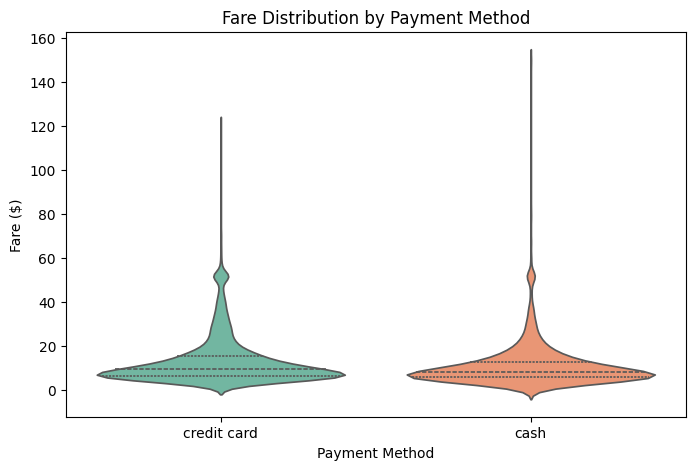

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1) Loading the Taxis Dataset
# ==========================================
df = sns.load_dataset("taxis")

# ==========================================
# 2) Handling Missing Values
# ==========================================
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Impute missing values
# Numerical columns: impute median
num_cols_with_na = df.select_dtypes(include=[np.number]).columns
for col in num_cols_with_na:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns: impute mode
cat_cols_with_na = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols_with_na:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# For critical columns that cannot be reasonably imputed, remove remaining rows (if any)
df = df.dropna()


# ==========================================
# 3) Visualizations using Matplotlib/Pandas Plot
# ==========================================

# Line Chart: Fare over time
df["pickup"] = pd.to_datetime(df["pickup"])
df_sorted = df.sort_values("pickup")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["pickup"], df_sorted["fare"], linewidth=0.8)
plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare ($)")
plt.grid(True)
plt.show()

# Bar Chart: Total fare for each pickup_borough
total_fare_borough = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(8, 5))
total_fare_borough.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=45)
plt.show()

# Pie Chart: Distribution of trips based on payment method
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Trip Distribution by Payment Method")
plt.show()

# Histogram: Distribution of distance
plt.figure(figsize=(8, 5))
plt.hist(df["distance"], bins=30, color="orange", edgecolor="black")
plt.title("Distribution of Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

# Box Plot: Tip amounts for each pickup_borough
plt.figure(figsize=(8, 5))
df.boxplot(column="tip", by="pickup_borough", grid=False)
plt.title("Tip Distribution by Pickup Borough")
plt.suptitle("")  # Suppress auto-generated title from pandas boxplot
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount ($)")
plt.xticks(rotation=45)
plt.show()


# ==========================================
# 4) Visualizations using Seaborn
# ==========================================

# Count Plot: Number of trips in each pickup_borough
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pickup_borough", palette="viridis")
plt.title("Trip Count per Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Count of Trips")
plt.show()

# Scatter Plot: Distance vs Fare colored by pickup_borough
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="distance", y="fare", hue="pickup_borough", alpha=0.7
)
plt.title("Distance vs Fare by Borough")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.show()

# Heatmap: Correlation matrix between numerical variables
plt.figure(figsize=(8, 6))
num_vars = ["distance", "fare", "tip", "tolls", "total"]
corr_matrix = df[num_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Pair Plot: Pairwise relationships colored by payment (or pickup_zone if preferred)
sns.pairplot(df, vars=["distance", "fare", "tip", "total"], hue="payment")
plt.suptitle("Pair Plot of Trip Metrics", y=1.02)
plt.show()

# Violin Plot: Fare distribution for each payment method
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df, x="payment", y="fare", palette="Set2", inner="quartile"
)
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.show()